In [1]:
install.packages(c(
  "data.table",
  "ggplot2",
  "dplyr",
  "lubridate",
  "purrr",
  "foreach",
  "doParallel",
  "microbenchmark"
), repos = "https://cloud.r-project.org")

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘iterators’




In [2]:
library(data.table)
library(ggplot2)
library(dplyr)
library(lubridate)
library(purrr)
library(foreach)
library(doParallel)
library(microbenchmark)


Attaching package: ‘data.table’


The following object is masked from ‘package:base’:

    %notin%



Attaching package: ‘dplyr’


The following objects are masked from ‘package:data.table’:

    between, first, last


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘lubridate’


The following objects are masked from ‘package:data.table’:

    hour, isoweek, isoyear, mday, minute, month, quarter, second, wday,
    week, yday, year


The following objects are masked from ‘package:base’:

    date, intersect, setdiff, union



Attaching package: ‘purrr’


The following object is masked from ‘package:data.table’:

    transpose



Attaching package: ‘foreach’


The following objects are masked from ‘package:purrr’:

    accumulate, when


Loading required package: iterators

Loading required package: parallel



In [5]:
taxi_url <- "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2025-01.parquet"

download.file(
  taxi_url,
  destfile = "yellow_tripdata_2025-01.parquet",
  mode = "wb"
)

zone_url <- "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv"

download.file(
  zone_url,
  destfile = "taxi_zone_lookup.csv",
  mode = "wb"
)

In [8]:
install.packages("arrow", repos = "https://cloud.r-project.org")
library(arrow)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘assertthat’



Attaching package: ‘arrow’


The following object is masked from ‘package:lubridate’:

    duration


The following object is masked from ‘package:utils’:

    timestamp




In [9]:
taxi <- as.data.table(
  arrow::read_parquet("yellow_tripdata_2025-01.parquet")
)

zones <- fread("taxi_zone_lookup.csv")

cat("Rows:", nrow(taxi), "\n")
cat("Columns:", ncol(taxi), "\n")

Rows: 3475226 
Columns: 20 


In [10]:
str(taxi)

dim(taxi)

head(taxi)

summary(taxi)

Classes ‘data.table’ and 'data.frame':	3475226 obs. of  20 variables:
 $ VendorID             : int  1 1 1 2 2 2 1 1 1 2 ...
 $ tpep_pickup_datetime : POSIXct, format: "2025-01-01 00:18:38" "2025-01-01 00:32:40" ...
 $ tpep_dropoff_datetime: POSIXct, format: "2025-01-01 00:26:59" "2025-01-01 00:35:13" ...
 $ passenger_count      : int  1 1 1 3 3 2 0 0 0 1 ...
 $ trip_distance        : num  1.6 0.5 0.6 0.52 0.66 2.63 0.4 1.6 2.8 1.71 ...
 $ RatecodeID           : int  1 1 1 1 1 1 1 1 1 1 ...
 $ store_and_fwd_flag   : chr  "N" "N" "N" "N" ...
 $ PULocationID         : int  229 236 141 244 244 239 170 234 148 237 ...
 $ DOLocationID         : int  237 237 141 244 116 68 170 148 170 262 ...
 $ payment_type         : int  1 1 1 2 2 2 1 1 1 2 ...
 $ fare_amount          : num  10 5.1 5.1 7.2 5.8 19.1 4.4 12.1 19.1 11.4 ...
 $ extra                : num  3.5 3.5 3.5 1 1 1 3.5 3.5 3.5 1 ...
 $ mta_tax              : num  0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 ...
 $ tip_amount           : num

[1] 3475226      20

VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
<int>,<dttm>,<dttm>,<int>,<dbl>,<int>,<chr>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,2025-01-01 00:18:38,2025-01-01 00:26:59,1,1.60,1,N,229,237,1,10.0,3.5,0.5,3.00,0,1,18.00,2.5,0,0
1,2025-01-01 00:32:40,2025-01-01 00:35:13,1,0.50,1,N,236,237,1,5.1,3.5,0.5,2.02,0,1,12.12,2.5,0,0
1,2025-01-01 00:44:04,2025-01-01 00:46:01,1,0.60,1,N,141,141,1,5.1,3.5,0.5,2.00,0,1,12.10,2.5,0,0
2,2025-01-01 00:14:27,2025-01-01 00:20:01,3,0.52,1,N,244,244,2,7.2,1.0,0.5,0.00,0,1,9.70,0.0,0,0
2,2025-01-01 00:21:34,2025-01-01 00:25:06,3,0.66,1,N,244,116,2,5.8,1.0,0.5,0.00,0,1,8.30,0.0,0,0
2,2025-01-01 00:48:24,2025-01-01 01:08:26,2,2.63,1,N,239,68,2,19.1,1.0,0.5,0.00,0,1,24.10,2.5,0,0


    VendorID     tpep_pickup_datetime          tpep_dropoff_datetime        
 Min.   :1.000   Min.   :2024-12-31 20:47:55   Min.   :2024-12-18 07:52:40  
 1st Qu.:2.000   1st Qu.:2025-01-10 07:59:01   1st Qu.:2025-01-10 08:15:29  
 Median :2.000   Median :2025-01-17 15:41:33   Median :2025-01-17 15:59:34  
 Mean   :1.785   Mean   :2025-01-17 11:02:55   Mean   :2025-01-17 11:17:57  
 3rd Qu.:2.000   3rd Qu.:2025-01-24 19:34:06   3rd Qu.:2025-01-24 19:48:31  
 Max.   :7.000   Max.   :2025-02-01 00:00:44   Max.   :2025-02-01 23:44:11  
                                                                            
 passenger_count  trip_distance         RatecodeID     store_and_fwd_flag 
 Min.   :0.000    Min.   :0.000e+00   Min.   : 1.000   Length   :3475226  
 1st Qu.:1.000    1st Qu.:9.800e-01   1st Qu.: 1.000   N.unique :      2  
 Median :1.000    Median :1.670e+00   Median : 1.000   N.blank  :      0  
 Mean   :1.298    Mean   :5.855e+00   Mean   : 2.483   Min.nchar:      1  
 3rd Qu.:

In [11]:
missing_values <- sapply(taxi, function(x) sum(is.na(x)))

missing_values

VendorID  tpep_pickup_datetime tpep_dropoff_datetime 
                    0                     0                     0 
      passenger_count         trip_distance            RatecodeID 
               540149                     0                540149 
   store_and_fwd_flag          PULocationID          DOLocationID 
               540149                     0                     0 
         payment_type           fare_amount                 extra 
                    0                     0                     0 
              mta_tax            tip_amount          tolls_amount 
                    0                     0                     0 
improvement_surcharge          total_amount  congestion_surcharge 
                    0                     0                540149 
          Airport_fee    cbd_congestion_fee 
               540149                     0

In [12]:
taxi <- taxi[
  passenger_count > 0 &
  trip_distance > 0 &
  fare_amount >= 0 &
  total_amount >= 0
]

cat("Rows after cleaning:", nrow(taxi), "\n")

Rows after cleaning: 2817385 


In [13]:
taxi <- unique(taxi)

cat("Rows after removing duplicates:", nrow(taxi), "\n")

Rows after removing duplicates: 2817385 


In [14]:
taxi[, tpep_pickup_datetime := as.POSIXct(
  tpep_pickup_datetime,
  tz = "America/New_York"
)]

taxi[, tpep_dropoff_datetime := as.POSIXct(
  tpep_dropoff_datetime,
  tz = "America/New_York"
)]

In [15]:
taxi[, hour := hour(tpep_pickup_datetime)]

taxi[, day := day(tpep_pickup_datetime)]

taxi[, day_of_week := wday(
  tpep_pickup_datetime,
  label = TRUE,
  abbr = FALSE
)]

taxi[, month := month(
  tpep_pickup_datetime,
  label = TRUE,
  abbr = FALSE
)]

head(taxi[, .(
  tpep_pickup_datetime,
  hour,
  day,
  day_of_week,
  month
)])

tpep_pickup_datetime,hour,day,day_of_week,month
<dttm>,<int>,<int>,<ord>,<ord>
2024-12-31 19:18:38,19,31,Tuesday,December
2024-12-31 19:32:40,19,31,Tuesday,December
2024-12-31 19:44:04,19,31,Tuesday,December
2024-12-31 19:14:27,19,31,Tuesday,December
2024-12-31 19:21:34,19,31,Tuesday,December
2024-12-31 19:48:24,19,31,Tuesday,December


In [16]:
zones[, LocationID := LocationID]

pickup_zones <- zones[, .(
  PULocationID = LocationID,
  PUZone = Zone,
  PUBorough = Borough
)]

dropoff_zones <- zones[, .(
  DOLocationID = LocationID,
  DOZone = Zone,
  DOBorough = Borough
)]

In [17]:
taxi <- pickup_zones[taxi, on = "PULocationID"]

taxi <- dropoff_zones[taxi, on = "DOLocationID"]

head(taxi)

DOLocationID,DOZone,DOBorough,PULocationID,PUZone,PUBorough,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,⋯,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee,hour,day,day_of_week,month
<int>,<chr>,<chr>,<int>,<chr>,<chr>,<int>,<dttm>,<dttm>,<int>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<ord>,<ord>
237,Upper East Side South,Manhattan,229,Sutton Place/Turtle Bay North,Manhattan,1,2024-12-31 19:18:38,2024-12-31 19:26:59,1,⋯,0,1,18.00,2.5,0,0,19,31,Tuesday,December
237,Upper East Side South,Manhattan,236,Upper East Side North,Manhattan,1,2024-12-31 19:32:40,2024-12-31 19:35:13,1,⋯,0,1,12.12,2.5,0,0,19,31,Tuesday,December
141,Lenox Hill West,Manhattan,141,Lenox Hill West,Manhattan,1,2024-12-31 19:44:04,2024-12-31 19:46:01,1,⋯,0,1,12.10,2.5,0,0,19,31,Tuesday,December
244,Washington Heights South,Manhattan,244,Washington Heights South,Manhattan,2,2024-12-31 19:14:27,2024-12-31 19:20:01,3,⋯,0,1,9.70,0.0,0,0,19,31,Tuesday,December
116,Hamilton Heights,Manhattan,244,Washington Heights South,Manhattan,2,2024-12-31 19:21:34,2024-12-31 19:25:06,3,⋯,0,1,8.30,0.0,0,0,19,31,Tuesday,December
68,East Chelsea,Manhattan,239,Upper West Side South,Manhattan,2,2024-12-31 19:48:24,2024-12-31 20:08:26,2,⋯,0,1,24.10,2.5,0,0,19,31,Tuesday,December


In [18]:
trips_by_hour <- taxi[
  , .(Trips = .N),
  by = hour
][order(hour)]

trips_by_hour

hour,Trips
<int>,<int>
0,15385
1,34883
2,74178
3,105890
4,122273
5,133643
6,144672
7,157125
8,165971


In [19]:
trips_by_day <- taxi[
  , .(Trips = .N),
  by = day_of_week
]

trips_by_day

day_of_week,Trips
<ord>,<int>
Tuesday,396178
Wednesday,450724
Thursday,507799
Friday,497167
Saturday,393758
Sunday,271298
Monday,300461


In [20]:
taxi[, week := week(tpep_pickup_datetime)]

trips_by_week <- taxi[
  , .(Trips = .N),
  by = week
][order(week)]

trips_by_week

week,Trips
<dbl>,<int>
1,535829
2,655641
3,635719
4,666265
5,303076
53,20855


In [21]:
fare_by_hour <- taxi[
  , .(
    Average_Fare = mean(fare_amount, na.rm = TRUE),
    Total_Revenue = sum(total_amount, na.rm = TRUE),
    Trips = .N
  ),
  by = hour
][order(hour)]

fare_by_hour

hour,Average_Fare,Total_Revenue,Trips
<int>,<dbl>,<dbl>,<int>
0,27.06278,578215.7,15385
1,21.62805,1057730.2,34883
2,18.56091,2001134.8,74178
3,16.99460,2663476.4,105890
4,17.12864,3110648.0,122273
5,17.41055,3452297.0,133643
6,17.23435,3695358.9,144672
7,23.02435,4940479.2,157125
8,18.06527,4426486.6,165971


In [22]:
top_routes <- taxi[
  !is.na(PUZone) & !is.na(DOZone),
  .(Trips = .N),
  by = .(PUZone, DOZone)
][order(-Trips)]

head(top_routes, 10)

PUZone,DOZone,Trips
<chr>,<chr>,<int>
Upper East Side South,Upper East Side North,23458
Upper East Side North,Upper East Side South,20267
Upper East Side North,Upper East Side North,16409
Upper East Side South,Upper East Side South,15636
Midtown Center,Upper East Side South,10712
Upper East Side South,Midtown Center,9369
Midtown Center,Upper East Side North,9154
Upper West Side South,Upper West Side North,8876
Lincoln Square East,Upper West Side South,8569


In [23]:
revenue_routes <- taxi[
  !is.na(PUZone) & !is.na(DOZone),
  .(
    Total_Revenue = sum(total_amount, na.rm = TRUE),
    Trips = .N
  ),
  by = .(PUZone, DOZone)
][order(-Total_Revenue)]

head(revenue_routes, 10)

PUZone,DOZone,Total_Revenue,Trips
<chr>,<chr>,<dbl>,<int>
LaGuardia Airport,Astoria Park,863561.5,6
JFK Airport,Outside of NYC,681695.4,5523
JFK Airport,Times Sq/Theatre District,486068.8,5074
LaGuardia Airport,Times Sq/Theatre District,398749.8,5239
Upper East Side South,Upper East Side North,366563.1,23458
Upper East Side North,Upper East Side South,320363.7,20267
JFK Airport,Midtown South,300103.0,3106
JFK Airport,Clinton East,288545.0,3026
Times Sq/Theatre District,LaGuardia Airport,268824.2,3506


In [24]:
distance_fare <- taxi[
  trip_distance > 0 & fare_amount > 0,
  .(
    Trip_Distance = trip_distance,
    Fare = fare_amount
  )
]

head(distance_fare)

Trip_Distance,Fare
<dbl>,<dbl>
1.60,10.0
0.50,5.1
0.60,5.1
0.52,7.2
0.66,5.8
2.63,19.1


In [25]:
cor(
  taxi$trip_distance,
  taxi$fare_amount,
  use = "complete.obs"
)

[1] 0.003153839

In [26]:
payment_analysis <- taxi[
  , .(
    Trips = .N,
    Average_Fare = mean(fare_amount, na.rm = TRUE),
    Total_Revenue = sum(total_amount, na.rm = TRUE)
  ),
  by = payment_type
][order(-Trips)]

payment_analysis

payment_type,Trips,Average_Fare,Total_Revenue
<int>,<int>,<dbl>,<dbl>
1,2405364,17.87387,67239847.2
2,364522,18.05552,8618969.9
4,35632,45.72216,1843972.4
3,11867,18.45717,286320.9


In [27]:
payment_borough <- taxi[
  !is.na(PUBorough),
  .(Trips = .N),
  by = .(PUBorough, payment_type)
][order(PUBorough, -Trips)]

payment_borough

PUBorough,payment_type,Trips
<chr>,<int>,<int>
Bronx,1,5384
Bronx,2,447
Bronx,4,48
Bronx,3,27
Brooklyn,1,21796
Brooklyn,2,1878
Brooklyn,4,241
Brooklyn,3,113
EWR,1,74


In [28]:
numeric_cols <- taxi[, .(
  trip_distance,
  fare_amount,
  tip_amount,
  total_amount
)]

lapply(numeric_cols, mean, na.rm = TRUE)

$trip_distance
[1] 3.230452

$fare_amount
[1] 18.25203

$tip_amount
[1] 3.499707

$total_amount
[1] 27.68138

In [29]:
sample_data <- taxi[, .(
  trip_distance,
  fare_amount,
  tip_amount,
  total_amount
)]

apply(sample_data, 2, mean, na.rm = TRUE)

trip_distance   fare_amount    tip_amount  total_amount 
     3.230452     18.252034      3.499707     27.681382

In [30]:
map(
  taxi[, .(
    trip_distance,
    fare_amount,
    tip_amount,
    total_amount
  )],
  ~mean(.x, na.rm = TRUE)
)

$trip_distance
[1] 3.230452

$fare_amount
[1] 18.25203

$tip_amount
[1] 3.499707

$total_amount
[1] 27.68138

In [31]:
colMeans(
  taxi[, .(
    trip_distance,
    fare_amount,
    tip_amount,
    total_amount
  )],
  na.rm = TRUE
)

trip_distance   fare_amount    tip_amount  total_amount 
     3.230452     18.252034      3.499707     27.681382

In [32]:
taxi[
  , lapply(
    .(
      trip_distance,
      fare_amount,
      tip_amount,
      total_amount
    ),
    mean,
    na.rm = TRUE
  )
]

V1,V2,V3,V4
<dbl>,<dbl>,<dbl>,<dbl>
3.230452,18.25203,3.499707,27.68138


In [33]:
benchmark_result <- microbenchmark(

  apply_method = {
    apply(
      taxi[, .(
        trip_distance,
        fare_amount,
        tip_amount,
        total_amount
      )],
      2,
      mean,
      na.rm = TRUE
    )
  },

  lapply_method = {
    lapply(
      taxi[, .(
        trip_distance,
        fare_amount,
        tip_amount,
        total_amount
      )],
      mean,
      na.rm = TRUE
    )
  },

  map_method = {
    map(
      taxi[, .(
        trip_distance,
        fare_amount,
        tip_amount,
        total_amount
      )],
      ~mean(.x, na.rm = TRUE)
    )
  },

  vectorized_method = {
    colMeans(
      taxi[, .(
        trip_distance,
        fare_amount,
        tip_amount,
        total_amount
      )],
      na.rm = TRUE
    )
  },

  times = 5
)

benchmark_result

expr,time
<fct>,<dbl>
lapply_method,208383407
vectorized_method,150518220
lapply_method,134998470
vectorized_method,87109789
map_method,139183857
vectorized_method,235060845
apply_method,238547977
map_method,139603944
apply_method,498817034


In [34]:
summary(benchmark_result)

expr,min,lq,mean,median,uq,max,neval
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
apply_method,238.54798,294.55672,355.2384,311.1294,433.1409,498.8170,5
lapply_method,134.99847,139.40382,159.6769,140.9291,174.6700,208.3834,5
map_method,133.40679,139.18386,152.0887,139.6039,142.7645,205.4845,5
vectorized_method,85.99265,87.10979,148.2131,150.5182,182.3838,235.0608,5


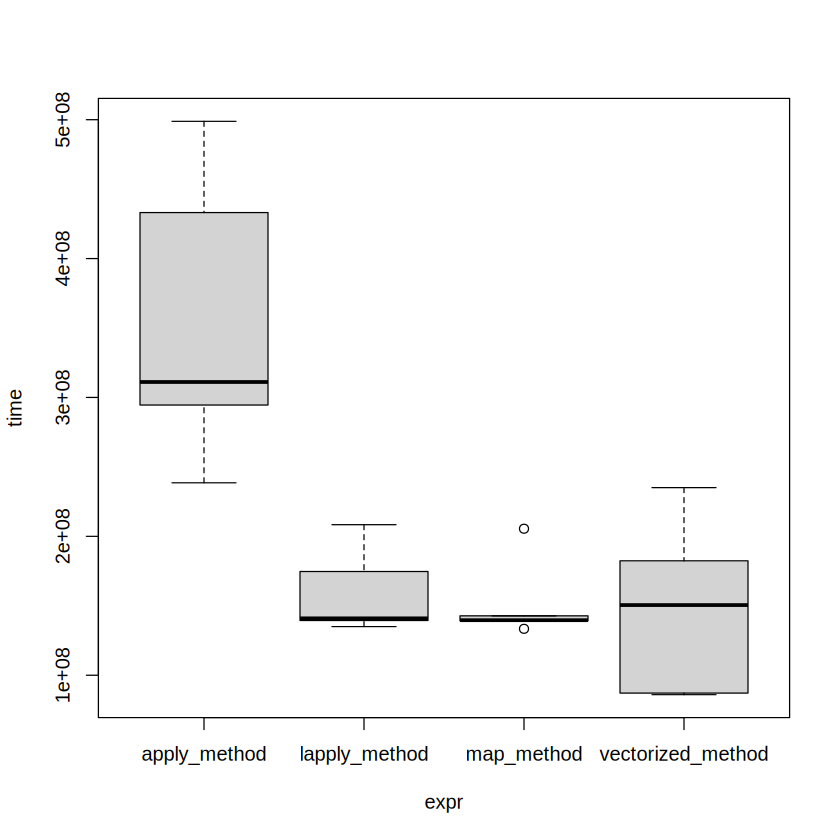

In [35]:
plot(benchmark_result)

In [36]:
taxi[, week := week(tpep_pickup_datetime)]

weekly_data <- split(taxi, taxi$week)

length(weekly_data)

[1] 6

In [37]:
start_time <- Sys.time()

sequential_result <- lapply(
  weekly_data,
  function(x) {
    x[, .(
      Trips = .N,
      Total_Revenue = sum(total_amount, na.rm = TRUE),
      Average_Fare = mean(fare_amount, na.rm = TRUE),
      Average_Distance = mean(trip_distance, na.rm = TRUE)
    )]
  }
)

end_time <- Sys.time()

sequential_time <- as.numeric(
  difftime(end_time, start_time, units = "secs")
)

sequential_time

[1] 0.2490425

In [38]:
cores <- max(1, parallel::detectCores() - 1)

cores

[1] 1

In [39]:
cl <- makeCluster(cores)

registerDoParallel(cl)

In [40]:
start_time <- Sys.time()

parallel_result <- foreach(
  x = weekly_data,
  .combine = rbind,
  .packages = "data.table"
) %dopar% {

  x[, .(
    Trips = .N,
    Total_Revenue = sum(total_amount, na.rm = TRUE),
    Average_Fare = mean(fare_amount, na.rm = TRUE),
    Average_Distance = mean(trip_distance, na.rm = TRUE)
  )]
}

end_time <- Sys.time()

parallel_time <- as.numeric(
  difftime(end_time, start_time, units = "secs")
)

parallel_time

[1] 5.44155

In [41]:
stopCluster(cl)

registerDoSEQ()

In [42]:
speedup <- sequential_time / parallel_time

speedup

[1] 0.04576684

In [43]:
performance <- data.table(
  Method = c(
    "Sequential",
    "Parallel"
  ),
  Execution_Time_Seconds = c(
    sequential_time,
    parallel_time
  )
)

performance[, Speedup := sequential_time /
              Execution_Time_Seconds]

performance

Method,Execution_Time_Seconds,Speedup
<chr>,<dbl>,<dbl>
Sequential,0.2490425,1.00000000
Parallel,5.4415495,0.04576684


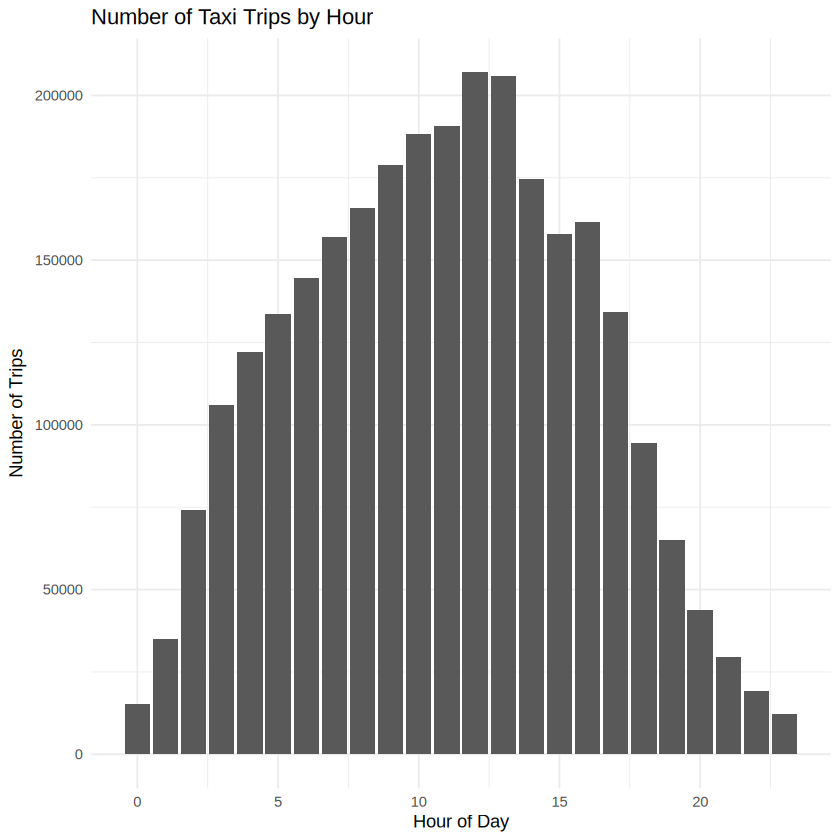

In [44]:
ggplot(
  trips_by_hour,
  aes(x = hour, y = Trips)
) +
  geom_col() +
  labs(
    title = "Number of Taxi Trips by Hour",
    x = "Hour of Day",
    y = "Number of Trips"
  ) +
  theme_minimal()

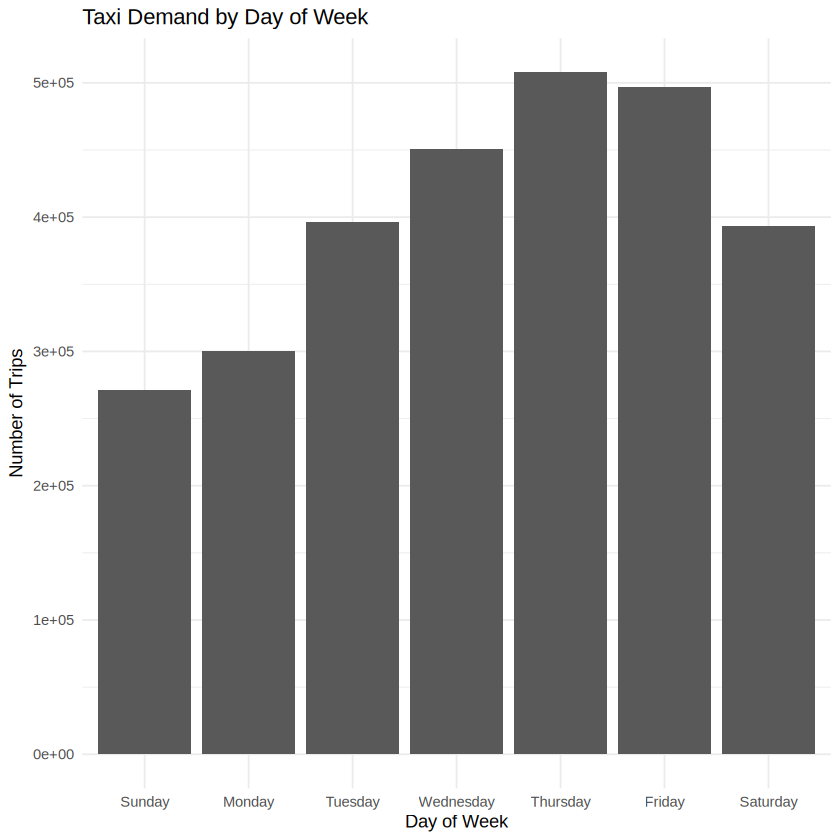

In [45]:
ggplot(
  trips_by_day,
  aes(x = day_of_week, y = Trips)
) +
  geom_col() +
  labs(
    title = "Taxi Demand by Day of Week",
    x = "Day of Week",
    y = "Number of Trips"
  ) +
  theme_minimal()

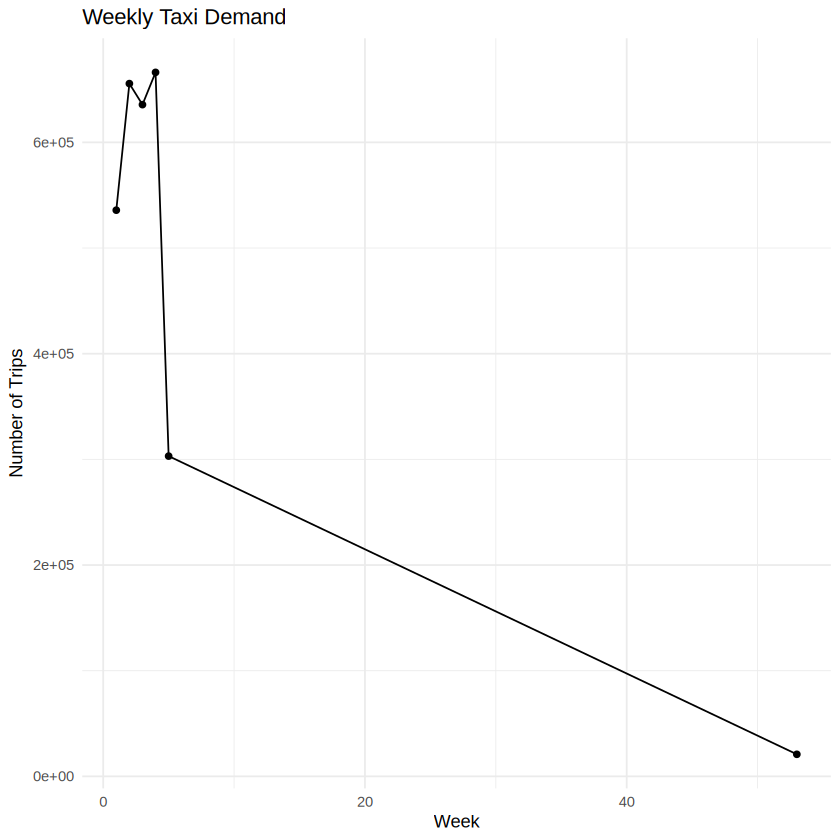

In [46]:
ggplot(
  trips_by_week,
  aes(x = week, y = Trips)
) +
  geom_line() +
  geom_point() +
  labs(
    title = "Weekly Taxi Demand",
    x = "Week",
    y = "Number of Trips"
  ) +
  theme_minimal()

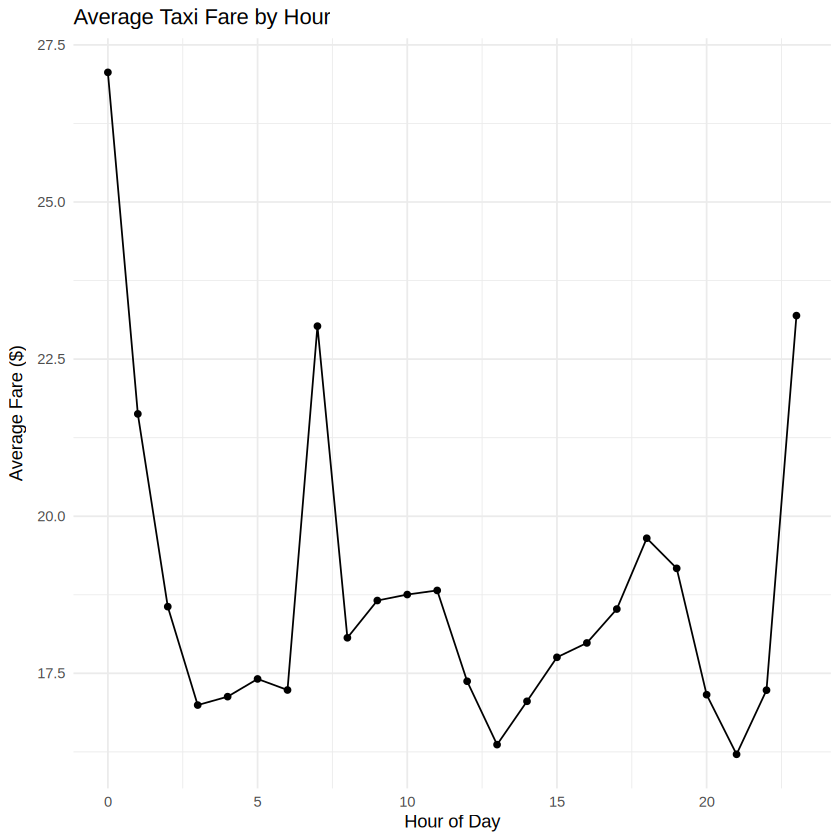

In [47]:
ggplot(
  fare_by_hour,
  aes(x = hour, y = Average_Fare)
) +
  geom_line() +
  geom_point() +
  labs(
    title = "Average Taxi Fare by Hour",
    x = "Hour of Day",
    y = "Average Fare ($)"
  ) +
  theme_minimal()

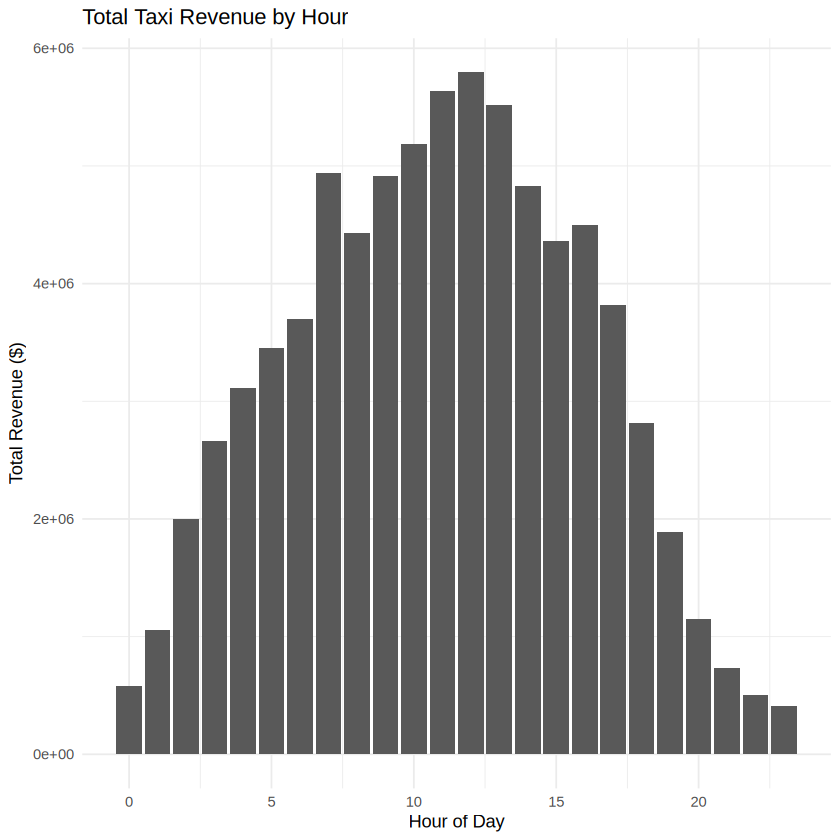

In [48]:
ggplot(
  fare_by_hour,
  aes(x = hour, y = Total_Revenue)
) +
  geom_col() +
  labs(
    title = "Total Taxi Revenue by Hour",
    x = "Hour of Day",
    y = "Total Revenue ($)"
  ) +
  theme_minimal()

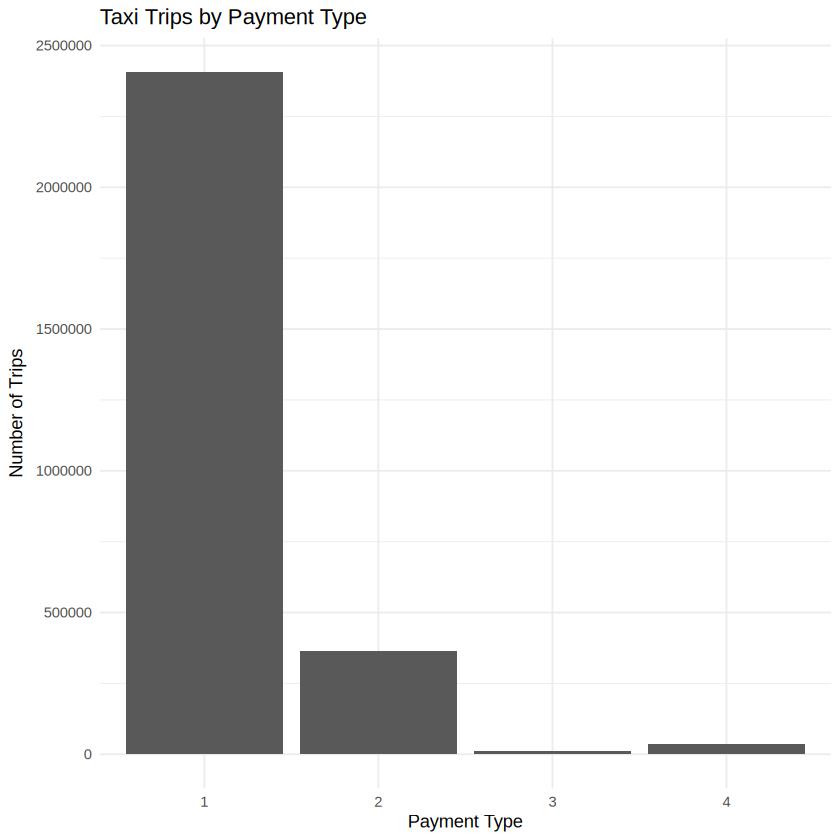

In [49]:
ggplot(
  payment_analysis,
  aes(
    x = factor(payment_type),
    y = Trips
  )
) +
  geom_col() +
  labs(
    title = "Taxi Trips by Payment Type",
    x = "Payment Type",
    y = "Number of Trips"
  ) +
  theme_minimal()

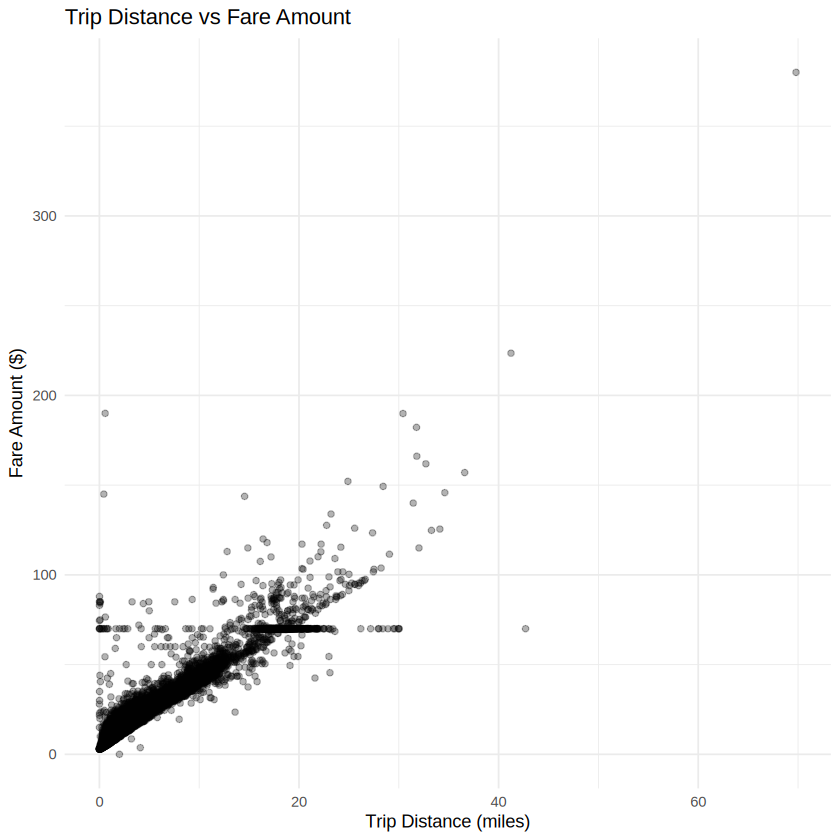

In [50]:
set.seed(123)

plot_data <- taxi[
  trip_distance > 0 &
  fare_amount > 0
][
  sample(.N, min(.N, 20000))
]

ggplot(
  plot_data,
  aes(
    x = trip_distance,
    y = fare_amount
  )
) +
  geom_point(alpha = 0.3) +
  labs(
    title = "Trip Distance vs Fare Amount",
    x = "Trip Distance (miles)",
    y = "Fare Amount ($)"
  ) +
  theme_minimal()

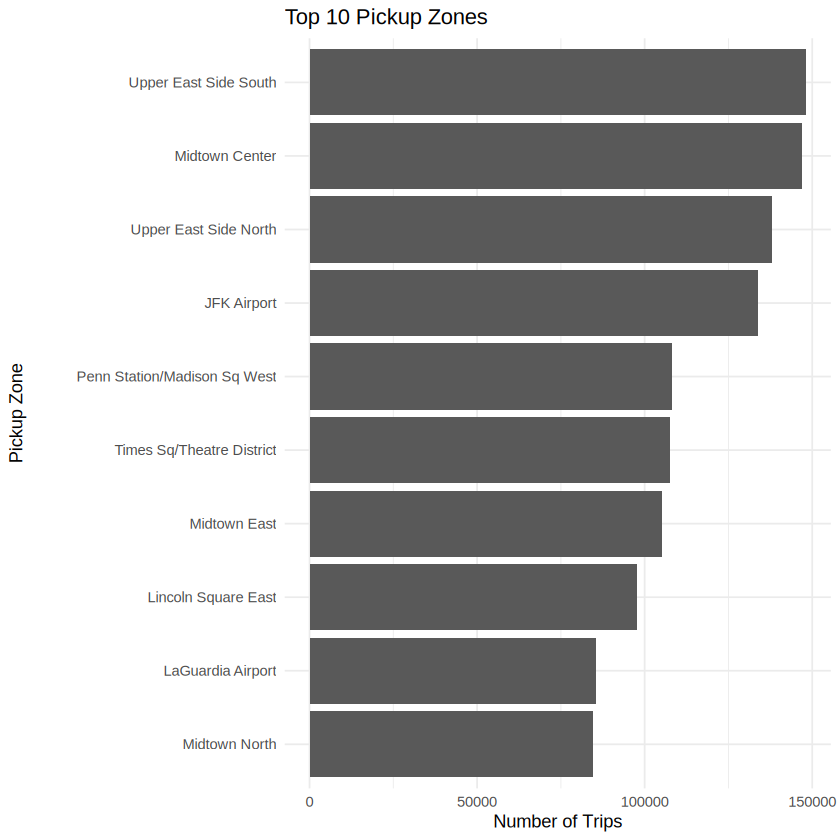

In [51]:
top_pickups <- taxi[
  !is.na(PUZone),
  .(Trips = .N),
  by = PUZone
][order(-Trips)][1:10]

ggplot(
  top_pickups,
  aes(
    x = reorder(PUZone, Trips),
    y = Trips
  )
) +
  geom_col() +
  coord_flip() +
  labs(
    title = "Top 10 Pickup Zones",
    x = "Pickup Zone",
    y = "Number of Trips"
  ) +
  theme_minimal()

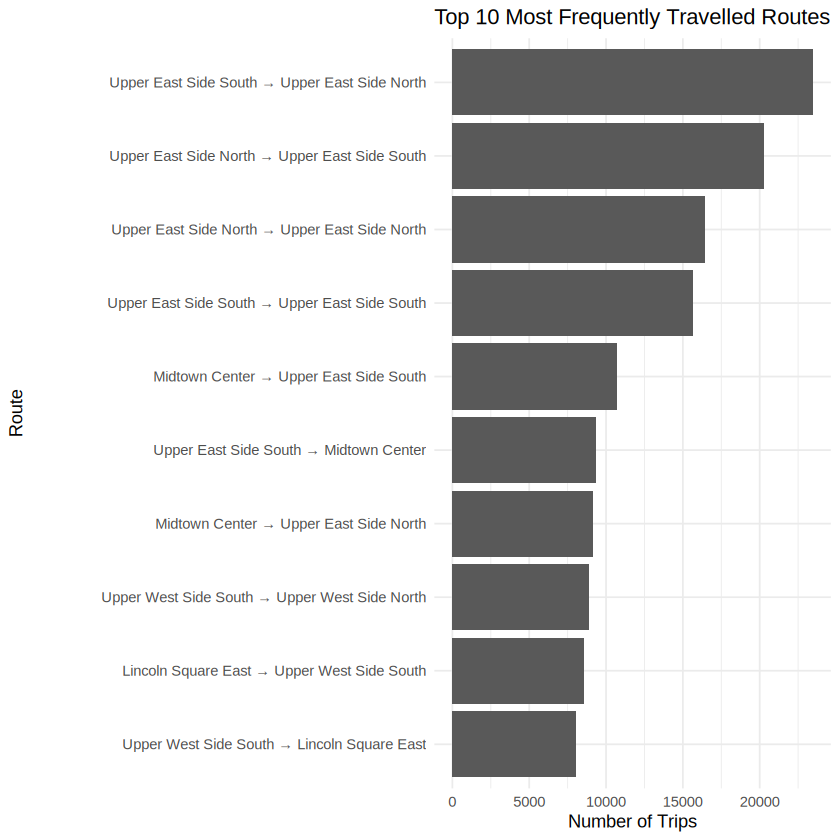

In [52]:
top_routes_plot <- top_routes[1:10]

top_routes_plot[, Route :=
  paste(PUZone, "→", DOZone)
]

ggplot(
  top_routes_plot,
  aes(
    x = reorder(Route, Trips),
    y = Trips
  )
) +
  geom_col() +
  coord_flip() +
  labs(
    title = "Top 10 Most Frequently Travelled Routes",
    x = "Route",
    y = "Number of Trips"
  ) +
  theme_minimal()

In [54]:
# Get benchmark summary
bench_summary <- summary(benchmark_result)

# View results
bench_summary

expr,min,lq,mean,median,uq,max,neval
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
apply_method,238.54798,294.55672,355.2384,311.1294,433.1409,498.8170,5
lapply_method,134.99847,139.40382,159.6769,140.9291,174.6700,208.3834,5
map_method,133.40679,139.18386,152.0887,139.6039,142.7645,205.4845,5
vectorized_method,85.99265,87.10979,148.2131,150.5182,182.3838,235.0608,5


In [55]:
comparison <- data.frame(
  Approach = as.character(bench_summary$expr),
  Median_Time_ms = bench_summary$median / 1e6
)

comparison

Approach,Median_Time_ms
<chr>,<dbl>
apply_method,0.0003111294
lapply_method,0.0001409291
map_method,0.0001396039
vectorized_method,0.0001505182


In [56]:
comparison <- rbind(
  data.frame(
    Approach = as.character(bench_summary$expr),
    Execution_Time_ms = bench_summary$median / 1e6
  ),
  data.frame(
    Approach = c("Sequential", "Parallel"),
    Execution_Time_ms = c(
      sequential_time * 1000,
      parallel_time * 1000
    )
  )
)

comparison

Approach,Execution_Time_ms
<chr>,<dbl>
apply_method,3.111294e-04
lapply_method,1.409291e-04
map_method,1.396039e-04
vectorized_method,1.505182e-04
Sequential,2.490425e+02
Parallel,5.441550e+03


In [57]:
comparison

Approach,Execution_Time_ms
<chr>,<dbl>
apply_method,3.111294e-04
lapply_method,1.409291e-04
map_method,1.396039e-04
vectorized_method,1.505182e-04
Sequential,2.490425e+02
Parallel,5.441550e+03
